Kelompok 5 - Anggota: Naila Aliyah, Mustika Angelia, Asyla Salsabil, Nayara Liflatul Nisa


Setup & Load Data


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('healthcare-dataset-stroke-data.csv', na_values=['N/A'])

Eksplorasi Data Awal

In [ ]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

print(df['stroke'].value_counts())
print(df['stroke'].value_counts(normalize=True) * 100)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB
None
                 id          age  hypertension  heart_disease  \
count   5110.000000  5110.000000   5110.000000    5110.000000   
mean   36517.829354   

Preprocessing

In [ ]:
# Drop kolom id
df = df.drop(columns=['id'])

# Isi missing value bmi dengan median
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

# Verifikasi tidak ada missing value lagi
print(df.isnull().sum())

# One-hot encoding
kategorikal_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
df_encoded = pd.get_dummies(df, columns=kategorikal_cols, drop_first=True)

print(df_encoded.columns.tolist())

# Pisahkan fitur dan target
X = df_encoded.drop(columns=['stroke'])
y = df_encoded['stroke']

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64
['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke', 'gender_Male', 'gender_Other', 'ever_married_Yes', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'Residence_type_Urban', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']


Split Data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Jumlah data training: {X_train.shape[0]}")
print(f"Jumlah data testing : {X_test.shape[0]}")

Jumlah data training: 4088
Jumlah data testing : 1022


Training Model

In [ ]:
model = DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)

Prediksi & Evaluasi

Accuracy  : 0.8288
Precision : 0.1795
Recall    : 0.7000
F1-Score  : 0.2857
              precision    recall  f1-score   support

Tidak Stroke       0.98      0.84      0.90       972
      Stroke       0.18      0.70      0.29        50

    accuracy                           0.83      1022
   macro avg       0.58      0.77      0.59      1022
weighted avg       0.94      0.83      0.87      1022

[[812 160]
 [ 15  35]]


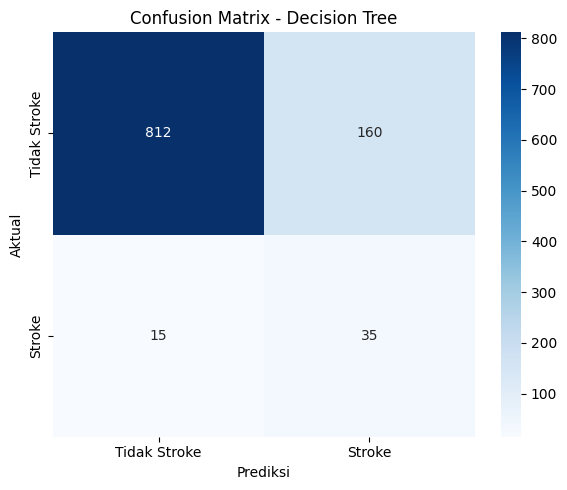

In [ ]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

print(classification_report(y_test, y_pred, target_names=['Tidak Stroke', 'Stroke']))

cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Stroke', 'Stroke'],
            yticklabels=['Tidak Stroke', 'Stroke'])
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix - Decision Tree')
plt.tight_layout()
plt.show()

Visualisasi Tambahan

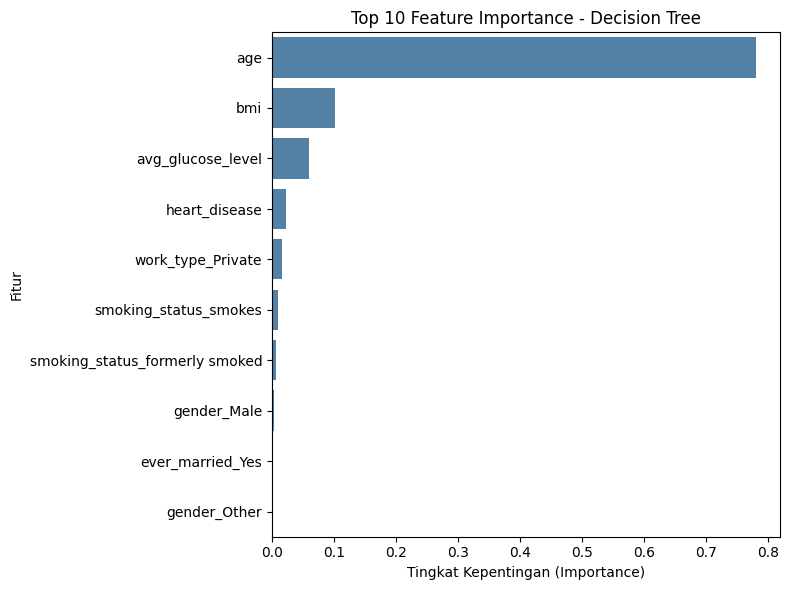

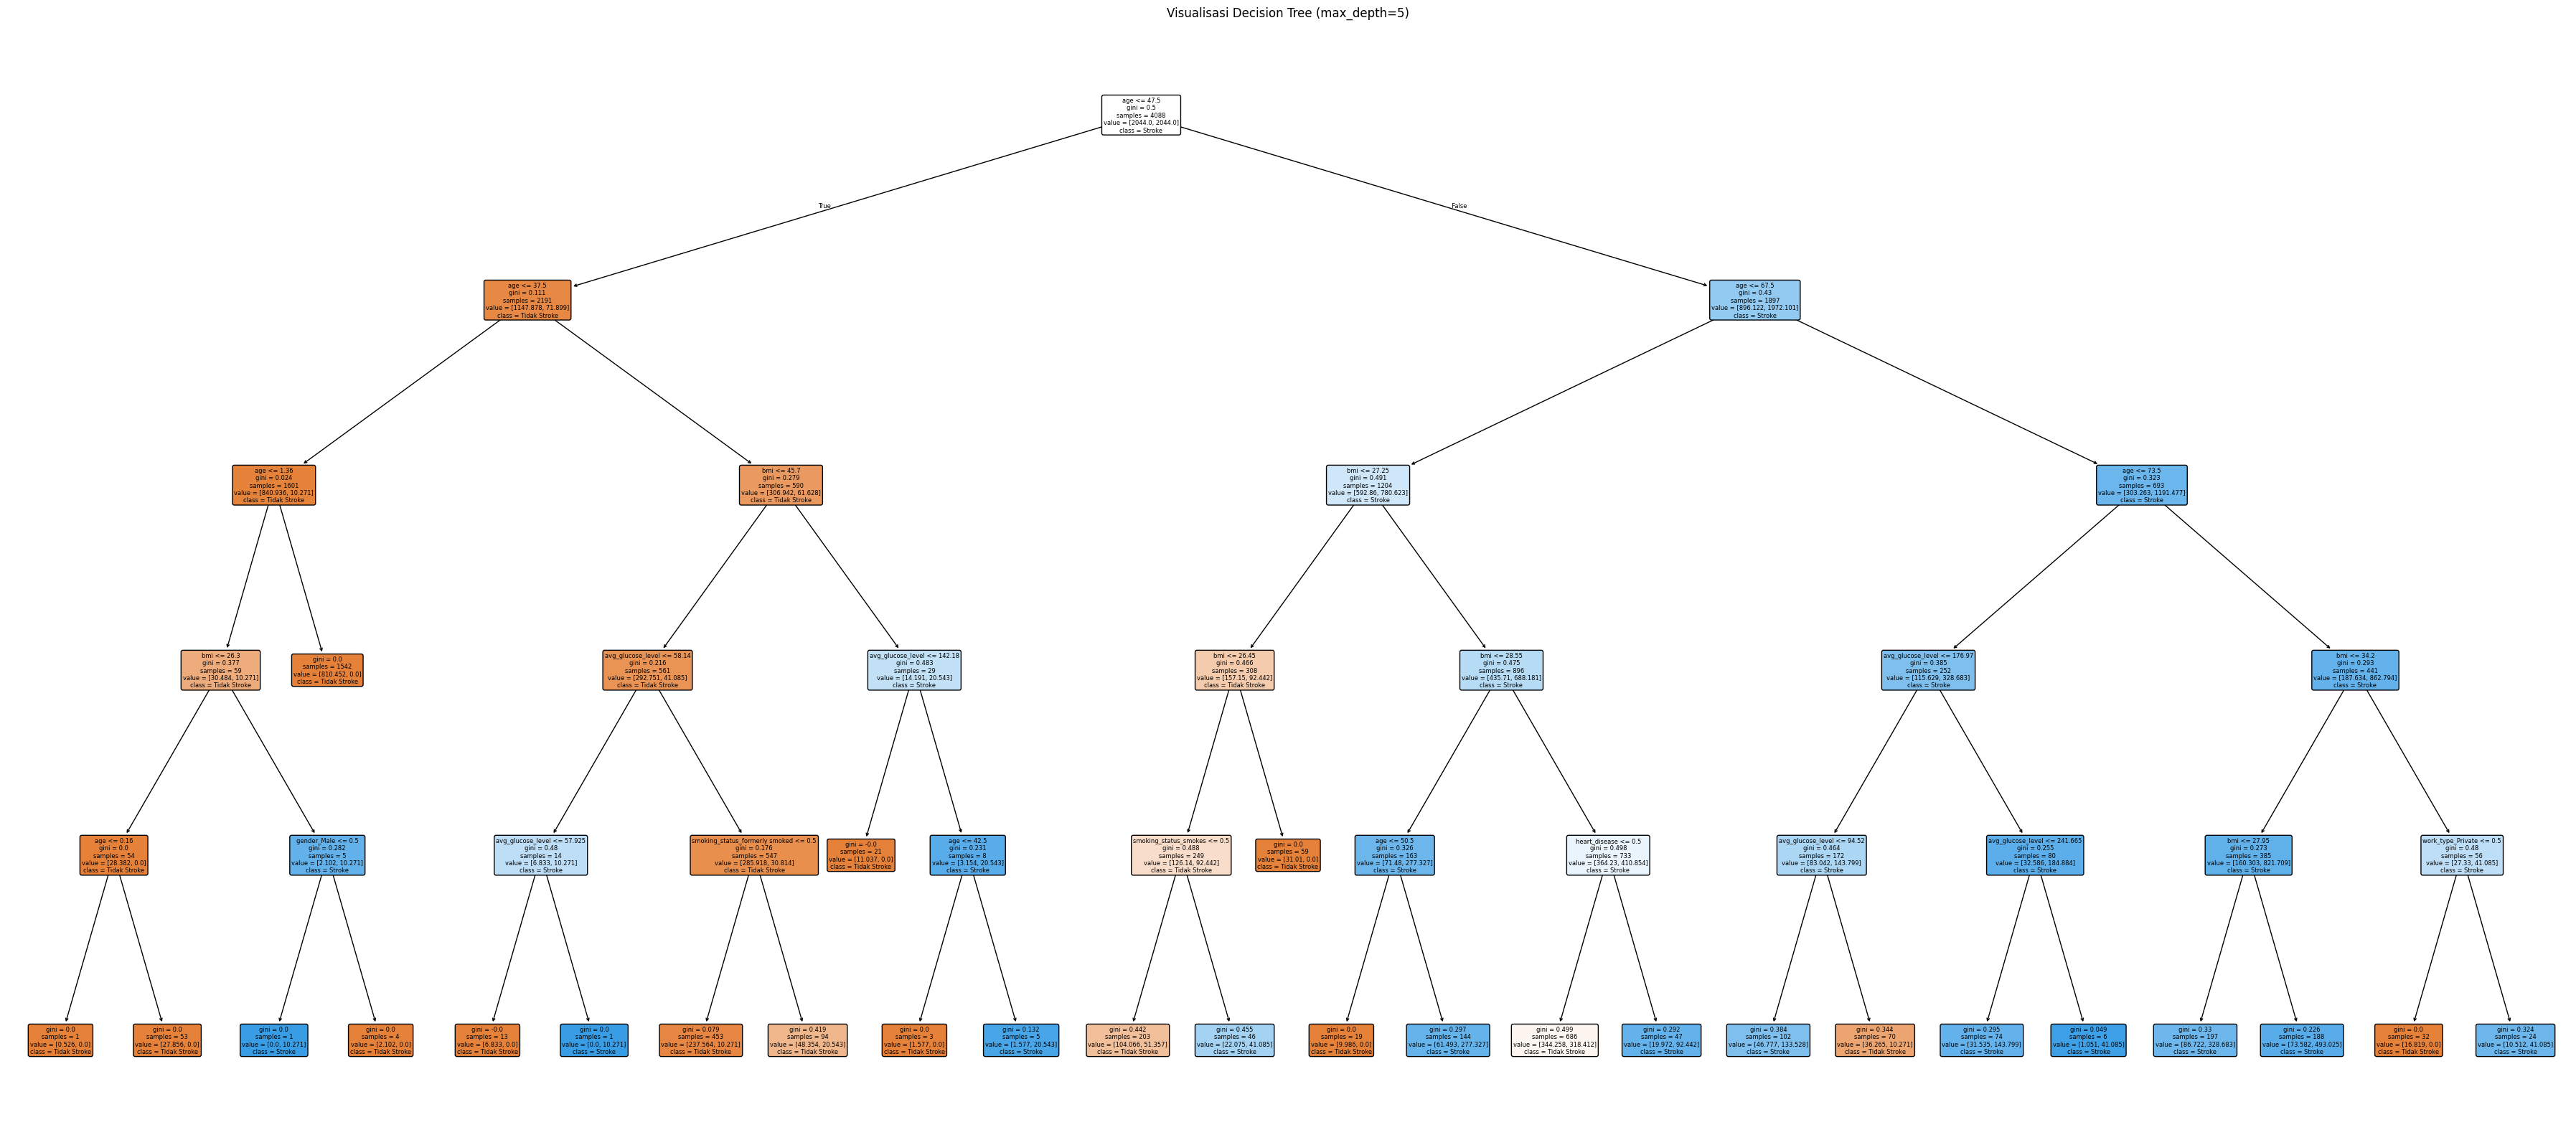

In [ ]:
# Feature importance
importances = pd.Series(model.feature_importances_, index=X.columns, name='importance')
importances.index.name = 'Fitur'
importances = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, color='steelblue')
plt.xlabel('Tingkat Kepentingan (Importance)')
plt.title('Top 10 Feature Importance - Decision Tree')
plt.tight_layout()
plt.show()

# Visualisasi pohon (sama dengan model utama, max_depth=5)
model_viz = DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)
model_viz.fit(X_train, y_train)

plt.figure(figsize=(36, 16))
plot_tree(model_viz, feature_names=X.columns, class_names=['Tidak Stroke', 'Stroke'],
          filled=True, rounded=True, fontsize=6)
plt.title('Visualisasi Decision Tree (max_depth=5)')
plt.tight_layout()
plt.savefig('decision_tree.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
print(importances)

Fitur
age                               0.780802
bmi                               0.102229
avg_glucose_level                 0.059181
heart_disease                     0.022247
work_type_Private                 0.015932
smoking_status_smokes             0.009114
smoking_status_formerly smoked    0.007038
gender_Male                       0.003457
ever_married_Yes                  0.000000
gender_Other                      0.000000
Name: importance, dtype: float64
